# Fundraising profiles

This notebook builds simple candidate fundraising profiles for the 2024 Portland City Council election.

We use four related fundraising representations across contribution-size bins:

1. **amount** — dollars raised in each contribution-size bin;
2. **amount_share** — share of a candidate's total dollars coming from each bin;
3. **contribution_count** — number of contribution records in each bin;
4. **contribution_share** — share of a candidate's contribution records in each bin.


## 1. Setup


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

YEAR = 2024


# ---------------------------------------------------------
# Find repository root
# ---------------------------------------------------------

cwd = Path.cwd()

if (cwd / "pyproject.toml").exists():
    ROOT = cwd

elif (cwd.parent / "pyproject.toml").exists():
    ROOT = cwd.parent

else:
    raise FileNotFoundError(
        "Could not find the repository root. "
        "Expected pyproject.toml in the current "
        "directory or its parent."
    )


# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

CONTRIBUTIONS_PATH = (
    ROOT
    / "data"
    / "clean"
    / "portland_contributions"
    / "contributions.csv"
)

CROSSWALK_PATH = (
    ROOT
    / "data"
    / "processed"
    / "master"
    / f"candidate_source_crosswalk_{YEAR}.csv"
)

OUTPUT_DIR = (
    ROOT
    / "data"
    / "processed"
    / "fundraising"
    / str(YEAR)
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("Repository root:")
print(ROOT)

print("\nContributions:")
print(CONTRIBUTIONS_PATH)
print("Exists:", CONTRIBUTIONS_PATH.exists())

print("\nCrosswalk:")
print(CROSSWALK_PATH)
print("Exists:", CROSSWALK_PATH.exists())

Repository root:
/Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis

Contributions:
/Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/clean/portland_contributions/contributions.csv
Exists: True

Crosswalk:
/Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/master/candidate_source_crosswalk_2024.csv
Exists: True


## 2. Load the cleaned contribution records

In [5]:
contributions = pd.read_csv(
    CONTRIBUTIONS_PATH,
    low_memory=False,
)

print("Rows:", f"{len(contributions):,}")
print("Columns:", len(contributions.columns))

contributions.head()

Rows: 53,596
Columns: 24


,type,city,state,zip,amount,contributorType,contributionType,contributionSubType,date,matchAmount,oaeType,campaignId,campaignName,officeSought,batchId,source_file_group,longitude,latitude,isMiscCashContributionUnder100,district,year,candidate,candidate_norm,is_public_matching_contribution
0,contribution,Portland,OR,97202,25.0,individual,contribution,cash,NaN,250.0,matchable,177,Tom Sollitt 2026,Councilor District 3,batch-0,participant,NaN,NaN,NaN,3,2026,Tom Sollitt,tom sollitt,False
1,contribution,VANCOUVER,WA,98664,40.0,individual,contribution,cash,2026-08-06 07:00:00+00:00,NaN,allowable,164,Tiffany Koyama Lane 2026,Councilor District 3,batch-1,participant,NaN,NaN,NaN,3,2026,Tiffany Koyama Lane,tiffany koyama lane,False
2,contribution,PORTLAND,OR,97219,25.0,individual,contribution,cash,2026-08-06 07:00:00+00:00,NaN,matchable,163,Mitch Green 2026,Councilor District 4,batch-2,participant,NaN,NaN,NaN,4,2026,Mitch Green,mitch green,False
3,contribution,PORTLAND,OR,97214,25.0,individual,contribution,cash,2026-08-06 07:00:00+00:00,NaN,matchable,164,Tiffany Koyama Lane 2026,Councilor District 3,batch-3,participant,NaN,NaN,NaN,3,2026,Tiffany Koyama Lane,tiffany koyama lane,False
4,contribution,PORTLAND,OR,97202,50.0,individual,contribution,cash,2026-08-06 07:00:00+00:00,NaN,allowable,197,Angelita Morillo 2026,Councilor District 3,batch-4,participant,NaN,NaN,NaN,3,2026,Angelita Morillo,angelita morillo,False


In [6]:
print("Records by year:")
display(
    contributions["year"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nRecords by district:")
display(
    contributions.loc[
        contributions["year"].eq(YEAR),
        "district",
    ]
    .value_counts(dropna=False)
    .sort_index()
)

Records by year:


year
2024    43211
2026    10385
Name: count, dtype: int64


Records by district:


district
1     8313
2    13575
3    10261
4    11062
Name: count, dtype: int64

## 3. Restrict to the 2024 City Council analysis sample

For fundraising profiles we:

- keep 2024;
- keep Districts 1–4;
- exclude public matching contributions;
- require a numeric, positive contribution amount.

Public matching contributions are kept in the cleaned source data, but they are not treated as private fundraising in this analysis.

In [7]:
analysis = contributions.loc[
    contributions["year"].eq(YEAR)
    & contributions["district"].isin([1, 2, 3, 4])
].copy()

analysis["amount"] = pd.to_numeric(
    analysis["amount"],
    errors="coerce",
)

print("2024 records before analysis filters:", f"{len(analysis):,}")

if "is_public_matching_contribution" in analysis.columns:
    print(
        "Public matching contribution records:",
        int(
            analysis["is_public_matching_contribution"]
            .fillna(False)
            .astype(bool)
            .sum()
        ),
    )

print(
    "Missing amount:",
    int(analysis["amount"].isna().sum()),
)

print(
    "Non-positive amount:",
    int(analysis["amount"].le(0).fillna(False).sum()),
)

2024 records before analysis filters: 43,211
Public matching contribution records: 101
Missing amount: 0
Non-positive amount: 0


In [8]:
analysis = analysis.loc[
    ~analysis[
        "is_public_matching_contribution"
    ]
    .fillna(False)
    .astype(bool)
    & analysis["amount"].notna()
    & analysis["amount"].gt(0)
].copy()

print("Records in fundraising analysis sample:", f"{len(analysis):,}")
print("Raw finance candidate labels:", analysis["candidate"].nunique())

Records in fundraising analysis sample: 43,110
Raw finance candidate labels: 69


## 4. Map finance names to the official candidate universe

In [9]:
crosswalk = pd.read_csv(
    CROSSWALK_PATH,
    low_memory=False,
)

finance_crosswalk = crosswalk.loc[
    crosswalk["source"].eq("portland_contributions")
].copy()

print("Finance crosswalk rows:", len(finance_crosswalk))

display(
    finance_crosswalk[
        [
            "district",
            "source_candidate_name",
            "suggested_candidate",
            "classification",
            "match_method",
            "needs_review",
        ]
    ]
    .sort_values(
        ["district", "source_candidate_name"]
    )
)

Finance crosswalk rows: 69


,district,source_candidate_name,suggested_candidate,classification,match_method,needs_review
205,1,Candace Avalos,Candace Avalos,match,exact_normalized_name,False
206,1,Cayle Tern,Cayle Tern,match,exact_normalized_name,False
207,1,David Linn,David Linn,match,exact_normalized_name,False
208,1,Deian Salazar,Deian Salazar,match,exact_normalized_name,False
209,1,Doug Clove,Doug Clove,match,exact_normalized_name,False
...,...,...,...,...,...,...
269,4,Moses Ross,Moses Ross,match,exact_normalized_name,False
270,4,Olivia Clark,Olivia Clark,match,exact_normalized_name,False
271,4,Sarah Silkie,Sarah Silkie,match,exact_normalized_name,False
272,4,Stan Penkin,Stanley Penkin,match,human_review_match,False


In [10]:
matched_finance_crosswalk = (
    finance_crosswalk.loc[
        finance_crosswalk["classification"].eq("match"),
        [
            "year",
            "district",
            "source_candidate_name",
            "suggested_candidate",
            "suggested_candidate_key",
        ],
    ]
    .rename(
        columns={
            "suggested_candidate": "canonical_candidate",
            "suggested_candidate_key": "candidate_key",
        }
    )
    .drop_duplicates()
)

analysis = analysis.merge(
    matched_finance_crosswalk,
    left_on=[
        "year",
        "district",
        "candidate",
    ],
    right_on=[
        "year",
        "district",
        "source_candidate_name",
    ],
    how="left",
    validate="many_to_one",
)

print(
    "Contribution records linked to official candidates:",
    f"{analysis['canonical_candidate'].notna().sum():,}",
)

print(
    "Contribution records not linked to official candidates:",
    f"{analysis['canonical_candidate'].isna().sum():,}",
)

Contribution records linked to official candidates: 42,944
Contribution records not linked to official candidates: 166


In [11]:
unmatched_finance = (
    analysis.loc[
        analysis["canonical_candidate"].isna()
    ]
    .groupby(
        [
            "district",
            "candidate",
        ],
        as_index=False,
    )
    .agg(
        contribution_records=("candidate", "size"),
        total_amount=("amount", "sum"),
    )
    .sort_values(
        [
            "district",
            "total_amount",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

print("Unmatched finance-only candidate labels:")
display(unmatched_finance)

Unmatched finance-only candidate labels:


,district,candidate,contribution_records,total_amount
0,1,Sonja McKenzie,75,4214.0
2,2,John Middleton,42,5005.0
1,2,David Burnell,45,1943.0
3,3,Robin Ye,4,100.0


In [12]:
analysis = analysis.loc[
    analysis["canonical_candidate"].notna()
].copy()

print(
    "Official candidates with fundraising records:",
    analysis["canonical_candidate"].nunique(),
)

Official candidates with fundraising records: 65


## 5. Define contribution-size bins

| Bin | Contribution amount |
|---|---:|
| Micro | ≤ $25 |
| Small | > $25 and ≤ $100 |
| Medium | > $100 and ≤ $250 |
| Large | > $250 and ≤ $1,000 |
| Mega | > $1,000 |


In [13]:
BIN_LABELS = [
    "Micro",
    "Small",
    "Medium",
    "Large",
    "Mega",
]

analysis["contribution_bin"] = pd.cut(
    analysis["amount"],
    bins=[
        -np.inf,
        25,
        100,
        250,
        1000,
        np.inf,
    ],
    labels=BIN_LABELS,
    right=True,
    ordered=True,
)

display(
    analysis["contribution_bin"]
    .value_counts(sort=False)
)

contribution_bin
Micro     29844
Small      9944
Medium     1528
Large      1620
Mega          8
Name: count, dtype: int64

## 6. Build the long fundraising profile

In [14]:
profile_long = (
    analysis
    .groupby(
        [
            "year",
            "district",
            "candidate_key",
            "canonical_candidate",
            "contribution_bin",
        ],
        observed=False,
        as_index=False,
    )
    .agg(
        amount=("amount", "sum"),
        contribution_count=("amount", "size"),
    )
)

profile_long.head(10)

,year,district,candidate_key,canonical_candidate,contribution_bin,amount,contribution_count
0,2024,1,2024|1|candace avalos,Candace Avalos,Micro,15993.76,1081
1,2024,1,2024|1|candace avalos,Candace Avalos,Small,22049.96,353
2,2024,1,2024|1|candace avalos,Candace Avalos,Medium,7116.39,33
3,2024,1,2024|1|candace avalos,Candace Avalos,Large,9946.04,25
4,2024,1,2024|1|candace avalos,Candace Avalos,Mega,3787.65,2
5,2024,1,2024|1|cayle tern,Cayle Tern,Micro,3135.00,261
6,2024,1,2024|1|cayle tern,Cayle Tern,Small,3160.00,48
7,2024,1,2024|1|cayle tern,Cayle Tern,Medium,750.00,3
8,2024,1,2024|1|cayle tern,Cayle Tern,Large,350.00,1
9,2024,1,2024|1|cayle tern,Cayle Tern,Mega,0.00,0


In [15]:
candidate_totals = (
    profile_long
    .groupby(
        [
            "year",
            "district",
            "candidate_key",
            "canonical_candidate",
        ],
        as_index=False,
    )
    .agg(
        total_amount=("amount", "sum"),
        total_contribution_count=(
            "contribution_count",
            "sum",
        ),
    )
)

profile_long = profile_long.merge(
    candidate_totals,
    on=[
        "year",
        "district",
        "candidate_key",
        "canonical_candidate",
    ],
    how="left",
    validate="many_to_one",
)

profile_long["amount_share"] = (
    profile_long["amount"]
    / profile_long["total_amount"]
)

profile_long["contribution_share"] = (
    profile_long["contribution_count"]
    / profile_long["total_contribution_count"]
)

profile_long.head(10)

,year,district,candidate_key,canonical_candidate,contribution_bin,amount,contribution_count,total_amount,total_contribution_count,amount_share,contribution_share
0,2024,1,2024|1|candace avalos,Candace Avalos,Micro,15993.76,1081,58893.8,1494,0.271570,0.723561
1,2024,1,2024|1|candace avalos,Candace Avalos,Small,22049.96,353,58893.8,1494,0.374402,0.236278
2,2024,1,2024|1|candace avalos,Candace Avalos,Medium,7116.39,33,58893.8,1494,0.120834,0.022088
3,2024,1,2024|1|candace avalos,Candace Avalos,Large,9946.04,25,58893.8,1494,0.168881,0.016734
4,2024,1,2024|1|candace avalos,Candace Avalos,Mega,3787.65,2,58893.8,1494,0.064313,0.001339
5,2024,1,2024|1|cayle tern,Cayle Tern,Micro,3135.00,261,7395.0,313,0.423935,0.833866
6,2024,1,2024|1|cayle tern,Cayle Tern,Small,3160.00,48,7395.0,313,0.427316,0.153355
7,2024,1,2024|1|cayle tern,Cayle Tern,Medium,750.00,3,7395.0,313,0.101420,0.009585
8,2024,1,2024|1|cayle tern,Cayle Tern,Large,350.00,1,7395.0,313,0.047329,0.003195
9,2024,1,2024|1|cayle tern,Cayle Tern,Mega,0.00,0,7395.0,313,0.000000,0.000000


## 7. Validate the profiles

For every candidate:

- `amount_share` should sum to 1;
- `contribution_share` should sum to 1.

In [16]:
validation = (
    profile_long
    .groupby(
        [
            "year",
            "district",
            "candidate_key",
            "canonical_candidate",
        ],
        as_index=False,
    )
    .agg(
        amount_share_sum=("amount_share", "sum"),
        contribution_share_sum=("contribution_share", "sum"),
    )
)

validation["amount_share_ok"] = np.isclose(
    validation["amount_share_sum"],
    1.0,
)

validation["contribution_share_ok"] = np.isclose(
    validation["contribution_share_sum"],
    1.0,
)

print(
    "Amount-share profiles valid:",
    validation["amount_share_ok"].all(),
)

print(
    "Contribution-share profiles valid:",
    validation["contribution_share_ok"].all(),
)

display(validation.head())

Amount-share profiles valid: True
Contribution-share profiles valid: True


,year,district,candidate_key,canonical_candidate,amount_share_sum,contribution_share_sum,amount_share_ok,contribution_share_ok
0,2024,1,2024|1|candace avalos,Candace Avalos,1.0,1.0,True,True
1,2024,1,2024|1|cayle tern,Cayle Tern,1.0,1.0,True,True
2,2024,1,2024|1|david linn,David Linn,1.0,1.0,True,True
3,2024,1,2024|1|deian salazar,Deian Salazar,1.0,1.0,True,True
4,2024,1,2024|1|doug clove,Doug Clove,1.0,1.0,True,True


## 8. Candidate-level summary

Before looking at profile shape, it is useful to keep two basic scale variables:

- total amount raised;
- total contribution records.

We also calculate average contribution size as a simple descriptive variable.

In [17]:
candidate_summary = (
    analysis
    .groupby(
        [
            "year",
            "district",
            "candidate_key",
            "canonical_candidate",
        ],
        as_index=False,
    )
    .agg(
        total_amount=("amount", "sum"),
        total_contribution_count=("amount", "size"),
        average_contribution=("amount", "mean"),
        median_contribution=("amount", "median"),
    )
    .sort_values(
        [
            "district",
            "total_amount",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

display(candidate_summary.head(20))

,year,district,candidate_key,canonical_candidate,total_amount,total_contribution_count,average_contribution,median_contribution
9,2024,1,2024|1|steph routh,Steph Routh,76006.71,1975,38.484410,20.24
12,2024,1,2024|1|timur ender,Timur Ender,61809.84,1260,49.055429,20.00
0,2024,1,2024|1|candace avalos,Candace Avalos,58893.80,1494,39.420214,20.00
7,2024,1,2024|1|loretta smith,Loretta Smith,43744.96,517,84.613075,25.00
10,2024,1,2024|1|terrence hayes,Terrence Hayes,36108.05,963,37.495379,20.00
5,2024,1,2024|1|jamie dunphy,Jamie Dunphy,35174.53,1055,33.340787,10.00
8,2024,1,2024|1|noah ernst,Noah Ernst,12993.18,416,31.233606,20.00
1,2024,1,2024|1|cayle tern,Cayle Tern,7395.00,313,23.626198,10.00
2,2024,1,2024|1|david linn,David Linn,4776.99,130,36.746077,20.00
4,2024,1,2024|1|doug clove,Doug Clove,1505.00,13,115.769231,20.00


## 9. Create a wide profile table

The long table is easiest to inspect and plot.

For regressions and correlations, a wide table is more convenient: one row per candidate and one column per fundraising dimension × contribution bin.

In [18]:
metrics = [
    "amount",
    "amount_share",
    "contribution_count",
    "contribution_share",
]

wide_parts = []

for metric in metrics:
    part = (
        profile_long
        .pivot(
            index=[
                "year",
                "district",
                "candidate_key",
                "canonical_candidate",
            ],
            columns="contribution_bin",
            values=metric,
        )
        .reindex(
            columns=BIN_LABELS
        )
        .fillna(0)
    )

    part.columns = [
        f"{metric}_{str(bin_name).lower()}"
        for bin_name in part.columns
    ]

    wide_parts.append(part)

profile_wide = pd.concat(
    wide_parts,
    axis=1,
).reset_index()

profile_wide = profile_wide.merge(
    candidate_summary,
    on=[
        "year",
        "district",
        "candidate_key",
        "canonical_candidate",
    ],
    how="left",
    validate="one_to_one",
)

print("Candidate rows:", len(profile_wide))
print("Profile columns:", len(profile_wide.columns))

display(profile_wide.head())

Candidate rows: 65
Profile columns: 28


,year,district,candidate_key,canonical_candidate,amount_micro,amount_small,amount_medium,amount_large,amount_mega,amount_share_micro,amount_share_small,amount_share_medium,amount_share_large,amount_share_mega,contribution_count_micro,contribution_count_small,contribution_count_medium,contribution_count_large,contribution_count_mega,contribution_share_micro,contribution_share_small,contribution_share_medium,contribution_share_large,contribution_share_mega,total_amount,total_contribution_count,average_contribution,median_contribution
0,2024,1,2024|1|candace avalos,Candace Avalos,15993.76,22049.96,7116.39,9946.04,3787.65,0.271570,0.374402,0.120834,0.168881,0.064313,1081,353,33,25,2,0.723561,0.236278,0.022088,0.016734,0.001339,58893.80,1494,39.420214,20.0
1,2024,1,2024|1|cayle tern,Cayle Tern,3135.00,3160.00,750.00,350.00,0.00,0.423935,0.427316,0.101420,0.047329,0.000000,261,48,3,1,0,0.833866,0.153355,0.009585,0.003195,0.000000,7395.00,313,23.626198,10.0
2,2024,1,2024|1|david linn,David Linn,1272.00,2200.00,805.00,499.99,0.00,0.266276,0.460541,0.168516,0.104666,0.000000,91,34,4,1,0,0.700000,0.261538,0.030769,0.007692,0.000000,4776.99,130,36.746077,20.0
3,2024,1,2024|1|deian salazar,Deian Salazar,485.00,695.00,200.00,0.00,0.00,0.351449,0.503623,0.144928,0.000000,0.000000,41,12,1,0,0,0.759259,0.222222,0.018519,0.000000,0.000000,1380.00,54,25.555556,20.0
4,2024,1,2024|1|doug clove,Doug Clove,125.00,150.00,250.00,980.00,0.00,0.083056,0.099668,0.166113,0.651163,0.000000,8,2,1,2,0,0.615385,0.153846,0.076923,0.153846,0.000000,1505.00,13,115.769231,20.0


## 10. Quick exploratory plots

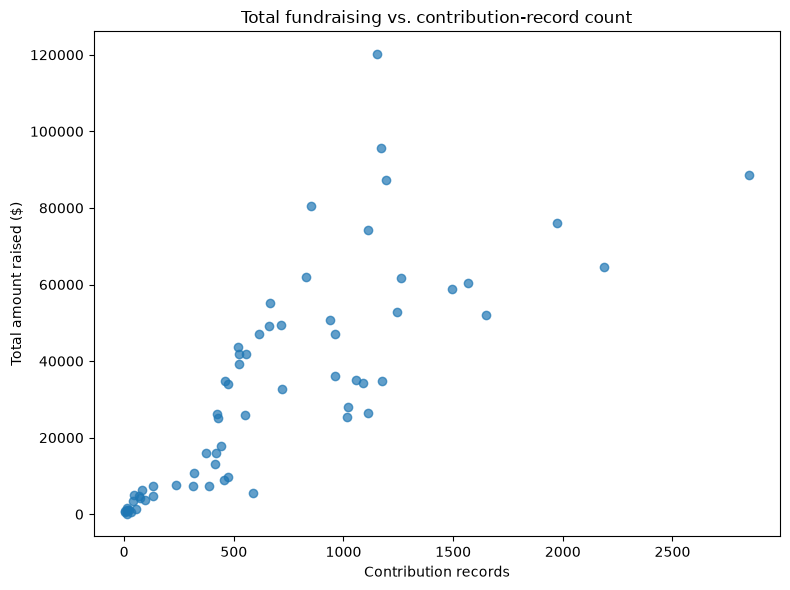

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    candidate_summary["total_contribution_count"],
    candidate_summary["total_amount"],
    alpha=0.7,
)

ax.set_xlabel("Contribution records")
ax.set_ylabel("Total amount raised ($)")
ax.set_title("Total fundraising vs. contribution-record count")

plt.tight_layout()
plt.show()

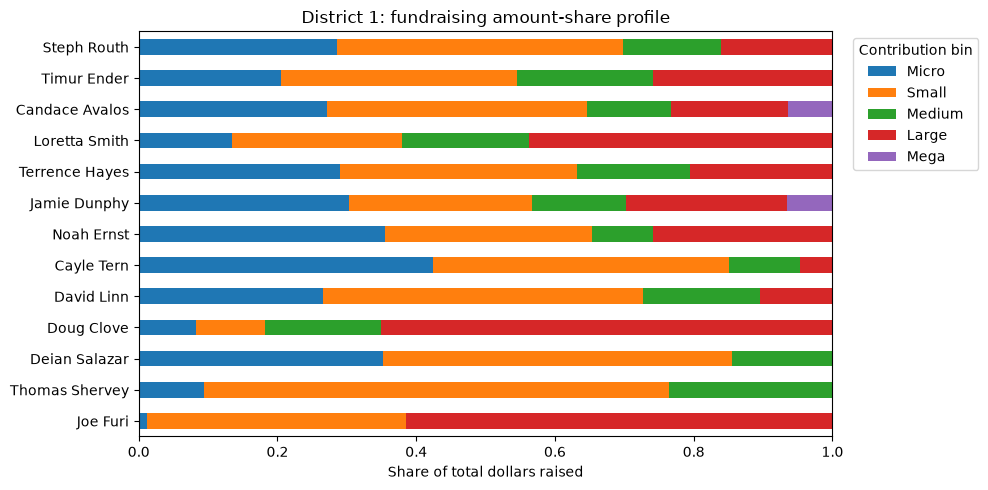

In [20]:
DISTRICT_TO_PLOT = 1

amount_share_plot = (
    profile_long.loc[
        profile_long["district"].eq(DISTRICT_TO_PLOT)
    ]
    .pivot(
        index="canonical_candidate",
        columns="contribution_bin",
        values="amount_share",
    )
    .reindex(columns=BIN_LABELS)
    .fillna(0)
)

candidate_order = (
    candidate_summary.loc[
        candidate_summary["district"].eq(DISTRICT_TO_PLOT)
    ]
    .sort_values(
        "total_amount",
        ascending=True,
    )["canonical_candidate"]
)

amount_share_plot = (
    amount_share_plot
    .reindex(candidate_order)
)

ax = amount_share_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(10, max(5, 0.35 * len(amount_share_plot))),
)

ax.set_xlabel("Share of total dollars raised")
ax.set_ylabel("")
ax.set_title(
    f"District {DISTRICT_TO_PLOT}: fundraising amount-share profile"
)

ax.legend(
    title="Contribution bin",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

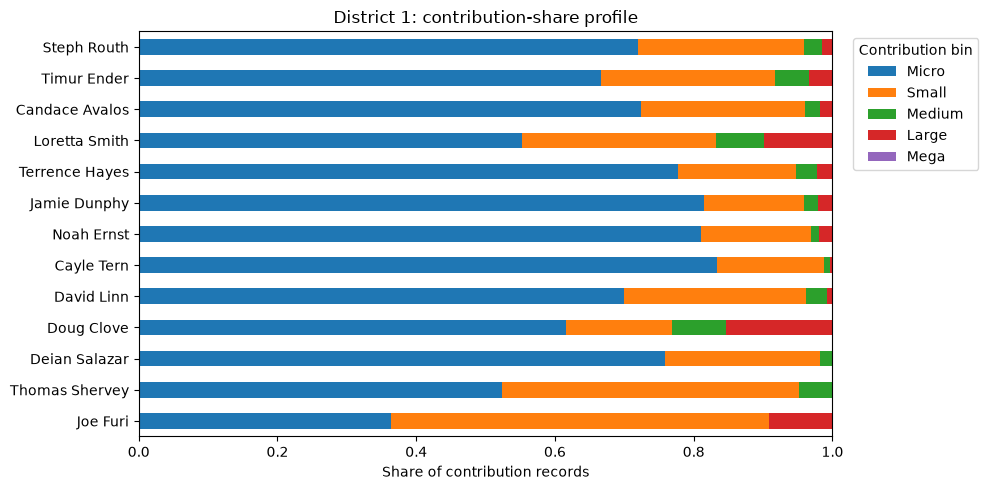

In [21]:
contribution_share_plot = (
    profile_long.loc[
        profile_long["district"].eq(DISTRICT_TO_PLOT)
    ]
    .pivot(
        index="canonical_candidate",
        columns="contribution_bin",
        values="contribution_share",
    )
    .reindex(columns=BIN_LABELS)
    .fillna(0)
    .reindex(candidate_order)
)

ax = contribution_share_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(10, max(5, 0.35 * len(contribution_share_plot))),
)

ax.set_xlabel("Share of contribution records")
ax.set_ylabel("")
ax.set_title(
    f"District {DISTRICT_TO_PLOT}: contribution-share profile"
)

ax.legend(
    title="Contribution bin",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

## 11. Export the exploratory fundraising profiles

In [22]:
long_path = (
    OUTPUT_DIR
    / "candidate_fundraising_profiles_long.csv"
)

wide_path = (
    OUTPUT_DIR
    / "candidate_fundraising_profiles_wide.csv"
)

summary_path = (
    OUTPUT_DIR
    / "candidate_fundraising_summary.csv"
)

profile_long.to_csv(
    long_path,
    index=False,
)

profile_wide.to_csv(
    wide_path,
    index=False,
)

candidate_summary.to_csv(
    summary_path,
    index=False,
)

print("SAVED", long_path)
print("SAVED", wide_path)
print("SAVED", summary_path)

SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2024/candidate_fundraising_profiles_long.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2024/candidate_fundraising_profiles_wide.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2024/candidate_fundraising_summary.csv
